# **House Prices Regression Project**

In this project, we use the Kaggle dataset:
**House Prices - Advanced Regression Techniques**.

The goal is to predict house sale prices (`SalePrice`) based on a set of features describing properties such as size, location, and quality.

The dataset is split into:
- **train.csv**: includes features and target variable
- **test.csv**: includes features only (used for final predictions)

## Library imports and Setup

In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [259]:
import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, Normalizer, StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
import sklearn_pandas
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split, cross_validate, KFold
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from scipy.special import boxcox1p
import csv
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [260]:
import sys
import scipy

print('Environment specification:\n')
print('python', '%s.%s.%s' % sys.version_info[:3])

for mod in np, scipy, sns, sklearn, pd:
    print(mod.__name__, mod.__version__)

Environment specification:

python 3.12.13
numpy 2.0.2
scipy 1.16.3
seaborn 0.13.2
sklearn 1.6.1
pandas 2.2.2


## Data

We load the training and test datasets using pandas and inspect the first rows to understand the structure and available features.

In [261]:
train_df = pd.read_csv("train.csv")
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [262]:
test_df = pd.read_csv("test.csv")
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [263]:
test_df_copy = test_df.copy()

## Exploratory Data Analysis and Data tidying

### Initial Data Inspection

We perform basic checks to understand the dataset:
- shape of the data
- data types (numerical vs categorical)
- presence of missing values

This step is essential to plan preprocessing.

In [264]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Target Variable Analysis

We analyze the distribution of the target variable (`SalePrice`).

The distribution is right-skewed, so we apply a log transformation (`log1p`) to:
- stabilize variance
- improve model performance
- make the distribution more normal

In [265]:
target = "SalePrice"

In [266]:
# Basic Summary
train_df[target].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


<Axes: ylabel='SalePrice'>

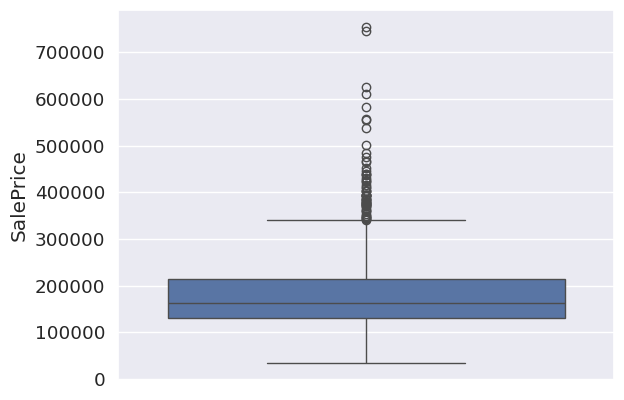

In [267]:
# Boxplot
sns.boxplot(train_df[target])

There are two outliers with prices more than 700000.

<Axes: xlabel='SalePrice', ylabel='Density'>

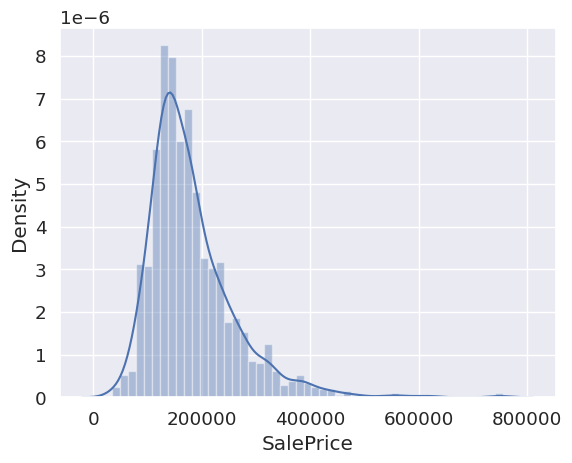

In [268]:
# The Density Plot of SalePrice
sns.distplot(train_df[target])

We can notice that it is right-skewed distribution with the pick around 160k and quite long tail with maximum about 800k.

In [269]:
# Positive Skeweness:
starting_skew = train_df[target].skew()
print(f"Starting Skewness: {starting_skew:.2f}")

Starting Skewness: 1.88


In order to be SalePrice more normal we do Logarithm transformation.

In [270]:
train_df[target] = np.log1p(train_df[target])

Text(0.5, 1.0, 'Density plot of SalePrice after Log Transformation')

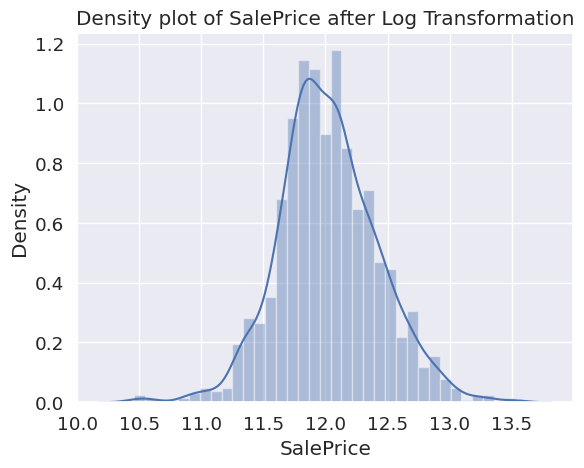

In [271]:
# SalePrice after Log-transformation
sns.distplot(train_df[target])
plt.title("Density plot of SalePrice after Log Transformation")

In [272]:
new_skew = train_df[target].skew()
print(f"New Skewness: {new_skew:.2f}")

New Skewness: 0.12


In [273]:
y = train_df[target]

### Missing Values
We analyze missing values to identify which features require imputation.

Handling missing data is crucial, as many machine learning models cannot deal with null values directly.

In [274]:
col_nan = train_df.isna().sum() / train_df.shape[0]

Text(0.5, 1.0, 'Features with the highest percentage of Nan values')

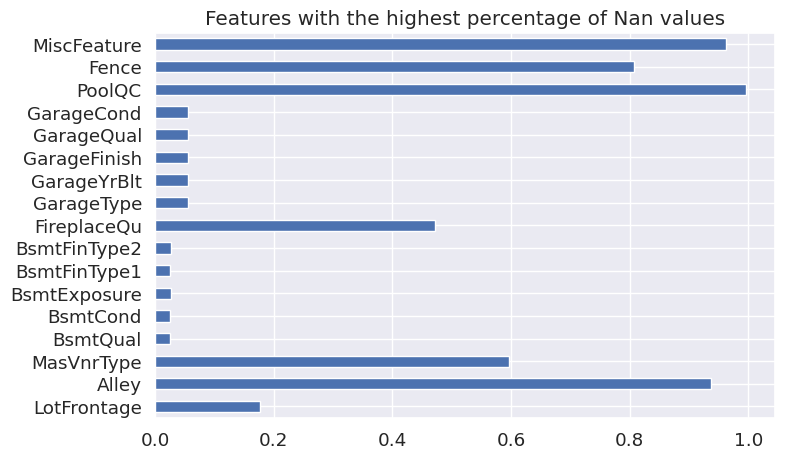

In [275]:
plt.figure(figsize=(8, 5))
sns.set(font_scale=1.2)
col_nan[col_nan > 0.01].plot(kind = "barh")
plt.title("Features with the highest percentage of Nan values")

### Removing ID column

We remove the ID column because this information is useless for the model

In [276]:
train_df.drop("Id", axis=1, inplace=True)
test_df.drop("Id", axis=1, inplace=True)

### Removing columns that contain the same value in 100%

In [277]:
def dominant_category_features_cat_only(df, threshold=0.95):
    result = []

    cat_cols = df.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        top_freq = df[col].value_counts(normalize=True).iloc[0]

        if top_freq >= threshold:
            result.append({
                "feature": col,
                "dominant_percentage": round(top_freq * 100, 2),
                "dominant_value": df[col].value_counts().index[0]
            })

    return pd.DataFrame(result).sort_values("dominant_percentage",
                                            ascending=False)

In [278]:
dominant_category_features_cat_only(train_df)

,feature,dominant_percentage,dominant_value
1,Utilities,99.93,AllPub
0,Street,99.59,Pave
2,Condition2,98.97,Norm
3,RoofMatl,98.22,CompShg
4,Heating,97.81,GasA
6,GarageCond,96.16,TA
5,GarageQual,95.07,TA


We'll drop for the moment only the features *Street* and *Utilities*

In [279]:
train_df.drop(["Street", "Utilities"], axis=1, inplace=True)
test_df.drop(["Street", "Utilities"], axis=1, inplace=True)

### Outlier drop

In this step, we analyze the relationship between the most correlated numerical features and the target variable (`SalePrice`) using scatter plots.\
This visual inspection helps identify potential outliers that could negatively impact model performance.

In [280]:
corr = train_df.corr(numeric_only=True)[target].sort_values(ascending=False)

top_features = corr.index[1:13]

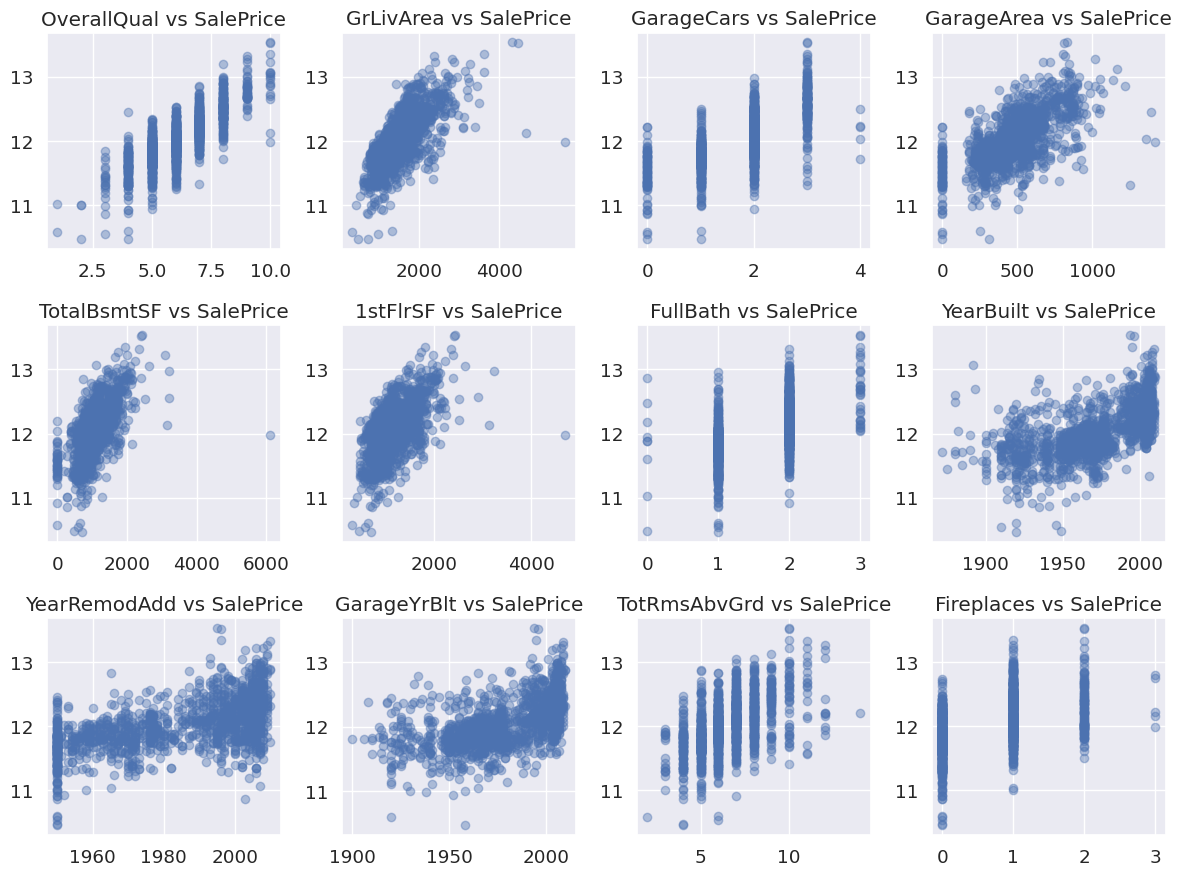

In [281]:
n_cols = 4
n_rows = int(np.ceil(len(top_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(train_df[col], train_df[target], alpha=0.4)
    axes[i].set_title(f"{col} vs {target}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From the plots, most features show a clear positive relationship with `SalePrice`, particularly:
- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `TotalBsmtSF`

However, we observe a small number of anomalies in `GrLivArea`: properties with unusually large living area but relatively low sale prices. These points do not follow the general trend and are likely to distort the model.

To improve model robustness, we remove these outliers by applying a threshold:
- `GrLivArea > 4000`
- `SalePrice < 300000` (log scale ≈ 12.5)

This targeted removal ensures that the dataset remains representative while reducing noise that could bias the learning process.

In [282]:
train_df = train_df[~((train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 12.5))]

## Preprocessing

In [283]:
X = train_df.drop(target, axis=1)
y = train_df[target]

In [284]:
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=42)

We separate features into:
- numerical features
- categorical features

In [285]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

Different preprocessing steps are applied:

- **Numerical features**:
  - Missing values → *median imputation*
  - Scaling → *StandardScaler*

- **Categorical features**:
  - Missing values → *most frequent value*
  - Encoding → *One-hot encoding*

We combine everything using a **`ColumnTransformer`** to ensure a clean and reproducible pipeline.

In [286]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])

cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                  sparse_output=False))])

preprocessor = ColumnTransformer([("num", num_pipeline, num_cols),
                                  ("cat", cat_pipeline, cat_cols)])

## Models

In [287]:
models = {"Linear": LinearRegression(),
          "Ridge": Ridge(alpha=1.0),
          "Lasso": Lasso(alpha=0.001),
          "ElasticNet": ElasticNet(alpha=0.001),
          "RF": RandomForestRegressor(),
          "GB": GradientBoostingRegressor()}

The selected models were chosen to cover a range of assumptions and levels of complexity, allowing for a comprehensive comparison of different learning approaches on the dataset.

- **Linear Regression**  
  Used as a baseline model to establish a simple reference point. It assumes a linear relationship between features and the target.

- **Ridge Regression**  
  Introduces L2 regularization to reduce overfitting and handle multicollinearity by shrinking coefficients.

- **Lasso Regression**  
  Applies L1 regularization, which can shrink some coefficients to zero, effectively performing feature selection.

- **ElasticNet**  
  Combines both L1 and L2 regularization, balancing the strengths of Ridge and Lasso, especially useful when dealing with many correlated features.

- **Random Forest Regressor**  
  An ensemble of decision trees that captures non-linear relationships and feature interactions. It is robust to noise and reduces overfitting through averaging.

- **Gradient Boosting Regressor**  
  A powerful ensemble method that builds trees sequentially, each correcting the errors of the previous ones. It is particularly effective for structured/tabular data and often achieves high predictive performance.

This combination allows us to compare:
- simple vs complex models  
- linear vs non-linear approaches  
- single models vs ensemble methods  

The goal is to identify the best trade-off between interpretability and predictive accuracy.

### Models selection

In [288]:
scoring = {"rmse": "neg_root_mean_squared_error",
           "mae": "neg_mean_absolute_error",
           "r2": "r2"}

In [289]:
results = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", model)])

    cv = cross_validate(pipe,
                        X,
                        y,
                        scoring=scoring,
                        cv=KFold(n_splits=10, shuffle=True, random_state=42),
                        return_train_score=False)

    results[name] = {"rmse_mean": -round(cv["test_rmse"].mean(),3),
                     "rmse_std": round(cv["test_rmse"].std(),3),
                     "mae_mean": -round(cv["test_mae"].mean(),3),
                     "r2_mean": round(cv["test_r2"].mean(),3)}

This procedure evaluates multiple regression models using a consistent and robust validation strategy based on cross-validation.
\
\
Each model is evaluated using a pipeline that includes both preprocessing and the estimator. This ensures that all transformations are applied correctly within each fold of cross-validation and prevents data leakage.

A K-Fold cross-validation strategy is used with shuffling and a fixed random state to ensure reproducibility and reliable performance estimates.
\
\
For each model, the following metrics are computed:
- **RMSE (Root Mean Squared Error)**: measures average prediction error, with lower values indicating better performance.
- **RMSE standard deviation**: measures model stability across folds.
- **MAE (Mean Absolute Error)**: provides a more interpretable measure of average error.
- **R² score**: indicates how well the model explains the variance in the target variable.

Since some scoring functions in scikit-learn return negative values, RMSE and MAE are multiplied by -1 to obtain interpretable results.
\
\
The results are stored in a dictionary where each model is associated with its aggregated performance metrics:
- mean performance across folds
- variability of performance (for robustness assessment)
- explanatory power of the model

\
This approach is designed to ensure a fair and consistent comparison between models by:
- evaluating all models on identical data splits
- integrating preprocessing within each validation fold
- using multiple metrics to capture both accuracy and stability
- reducing overfitting risk through cross-validation

Overall, this methodology provides a reliable basis for selecting the best-performing model while considering both predictive accuracy and generalization stability.

In [290]:
df = pd.DataFrame(results).T
df

,rmse_mean,rmse_std,mae_mean,r2_mean
Linear,0.123,0.019,0.085,0.902
Ridge,0.116,0.015,0.081,0.913
Lasso,0.113,0.014,0.079,0.918
ElasticNet,0.111,0.014,0.078,0.920
RF,0.137,0.013,0.095,0.881
GB,0.122,0.015,0.086,0.903


In [291]:
df["score"] = (df["rmse_mean"] +
               0.5 * df["rmse_std"] -
               0.2 * df["r2_mean"])

To select the best-performing model, a composite score is computed by combining multiple evaluation metrics into a single criterion.

The score is defined as:
- lower values indicate better models
- it balances accuracy, stability, and explanatory power

It is computed as

\begin{aligned}
\text{Score} &= \text{RMSE}_{mean} + 0.5 \cdot \text{RMSE}_{std} - 0.2 \cdot R^2_{mean}
\end{aligned}

- **RMSE mean**: represents the average prediction error; it is the most important component, as lower error directly indicates better performance.
- **RMSE standard deviation (weighted by 0.5)**: penalizes models that are unstable across cross-validation folds, favoring robustness.
- **R² score (weighted by 0.2)**: rewards models that explain more variance in the target variable.

A good model should:
- minimize prediction error (low RMSE)
- remain stable across different data splits (low variance)
- maintain strong explanatory power (high R²)

The score combines these aspects into a single metric to enable straightforward ranking and selection of the best model.

In [292]:
df = df.sort_values("score")
df

,rmse_mean,rmse_std,mae_mean,r2_mean,score
ElasticNet,0.111,0.014,0.078,0.920,-0.0660
Lasso,0.113,0.014,0.079,0.918,-0.0636
Ridge,0.116,0.015,0.081,0.913,-0.0591
GB,0.122,0.015,0.086,0.903,-0.0511
Linear,0.123,0.019,0.085,0.902,-0.0479
RF,0.137,0.013,0.095,0.881,-0.0327


In [293]:
best_model_name = df.index[0]
best_score = df["score"][0]

print(f"The best model is {best_model_name} with an RMSE of {best_score:.3f}")

The best model is ElasticNet with an RMSE of -0.066


### Train

In [294]:
best_model = Pipeline([("preprocessor", preprocessor),
                       ("model", models[best_rmse_model_name])])

In [295]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object'))])),
                ('model', ElasticNet(alpha=0.001))])

### Validation

After selecting the best-performing model, we evaluate its performance on the validation set.

Since the target variable was log-transformed during training, predictions are initially obtained on the log scale. For interpretability, we evaluate the model both:
- on the **log scale**, to remain consistent with training
- on the **original scale**, to understand real-world prediction error

This dual evaluation provides a more complete understanding of model performance.

In [296]:
preds = best_model.predict(X_val)

In [297]:
rmse_log = round(np.sqrt(mean_squared_error(y_val, preds)), 4)
print("RMSE (log):", rmse_log)

RMSE (log): 0.1172


The RMSE on the log-transformed target reflects how well the model fits the transformed data.

This metric is useful because:
- it stabilizes variance
- reduces the impact of extreme values
- aligns with how the model was trained

However, it is less intuitive for real-world interpretation.

In [298]:
preds_exp = np.expm1(preds)
y_val_exp = np.expm1(y_val)

rmse_real = round(np.sqrt(mean_squared_error(y_val_exp, preds_exp)),2)
print("RMSE (original scale):", rmse_real)

RMSE (original scale): 19455.13


To make results interpretable, predictions are converted back to the original scale using the inverse transformation.

The RMSE in the original scale represents the average prediction error in actual price units, making it easier to assess the practical impact of the model.

This is the most relevant metric for real-world evaluation.

In [299]:
residuals = y_val - preds

Residuals are defined as the difference between actual and predicted values.

Analyzing residuals helps us understand:
- whether the model is unbiased
- if errors are randomly distributed
- whether important patterns are still not captured

A well-performing model should produce residuals that are approximately normally distributed and centered around zero.

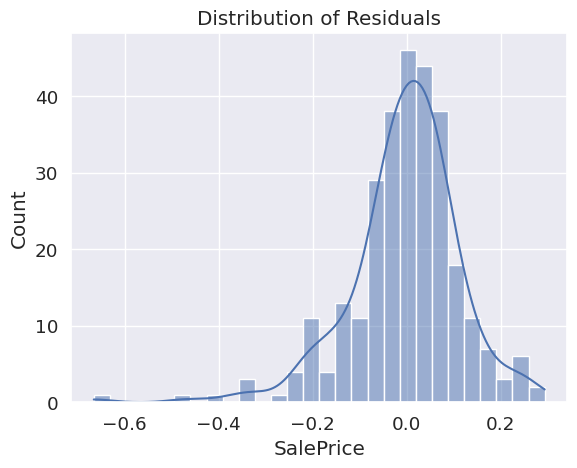

In [300]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

The histogram shows the distribution of residuals.

Key aspects to evaluate:
- symmetry around zero → indicates low bias  
- bell-shaped curve → suggests normality  
- absence of extreme outliers → indicates stable predictions  

Deviations from this pattern may indicate:
- model underfitting or overfitting  
- missing features  
- non-linear relationships not captured by the model  

In [301]:
residuals.describe()

,SalePrice
count,292.000000
mean,-0.004223
std,0.117348
min,-0.665925
25%,-0.055793
50%,0.003333
75%,0.061323
max,0.293215


Summary statistics provide a quantitative view of residual behavior:

- Mean close to 0 (-0.0042): very low global bias; predictions are well centered
- Standard deviation (~0.117): moderate spread; typical error magnitude is relatively stable
- Range [-0.666, 0.293]: asymmetric tail (more severe negative errors than positive ones)

This suggests:
- slight tendency toward underestimation in some cases (larger negative residuals)
- overall model stability is good, but tail behavior is not perfectly balanced

In [302]:
residual_factors = np.exp(residuals)
residual_factors.describe()

,SalePrice
count,292.000000
mean,1.002383
std,0.112066
min,0.513798
25%,0.945735
50%,1.003338
75%,1.063243
max,1.340731


Key Insights:
- **No systematic bias**:  
  The mean and median are very close to 1, indicating that the model does not consistently overestimate or underestimate prices.
- **High central accuracy**:  
  The interquartile range [0.946, 1.063] shows that 50% of predictions are within approximately ±6% of the true values.
- **Stable performance**:  
  The relatively low standard deviation (≈ 0.112) suggests consistent predictive behavior across most samples.
- **Few extreme errors**:  
  The model occasionally underestimates by up to ~49% and overestimates by ~34%, indicating the presence of outliers or hard-to-predict cases.


Overall, the model is well-calibrated and accurate for the majority of predictions, with strong generalization and limited error dispersion, though it still struggles on a small number of extreme cases.

## Predict

In [303]:
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object'))])),
                ('model', ElasticNet(alpha=0.001))])

In [304]:
test_preds = best_model.predict(test_df)

In [305]:
test_preds = np.expm1(test_preds)

In [306]:
test_preds = np.round(test_preds, 2)
test_preds

array([118927.15, 147826.45, 178003.  , ..., 170731.85, 118290.27,
       230385.47])

In [307]:
submission = pd.DataFrame({"Id": test_df_copy["Id"],
                           "SalePrice": test_preds})

In [308]:
submission.to_csv("submission.csv", index=False)